In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn pymongo


Note: you may need to restart the kernel to use updated packages.


# 📊 Análisis de Correlación y Separabilidad - fact_evaluacion_proveedores

## Objetivo:
1. Cargar datos desde MongoDB
2. Calcular matriz de correlación
3. Identificar features redundantes
4. Visualizar en t-SNE 2D
5. Recomendaciones de reducción

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import pymongo
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# Conectar MongoDB
try:
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["ProyectoBueno"]
    collection = db["fact_evaluacion_proveedores"]
    data = list(collection.find())
    print(f"✅ Registros cargados: {len(data)}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Registros cargados: 1500


In [4]:
# Aplanar datos
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"📊 Dimensiones: {df.shape}")

📊 Dimensiones: (1500, 70)


In [5]:
# Crear target basado en una métrica numérica
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 0:
    # Usar la primera métrica numérica para binaria
    y = pd.cut(df[numeric_cols[0]], bins=3, labels=[0, 1, 2]).astype(int)
    print(f"✅ Target MULTICLASE creado automáticamente (3 clases)")
    print(f"Distribución: {y.value_counts().to_dict()}")

✅ Target MULTICLASE creado automáticamente (3 clases)
Distribución: {0: 500, 1: 500, 2: 500}


In [6]:
# Limpieza
cols_to_drop = [col for col in df.columns if any(x in col.lower() for x in ['_id', 'id', 'email', 'name', 'fecha', 'date', 'codigo', 'nombre', 'correo', 'telefono', 'hora', 'collection'])]
df_clean = df.drop(columns=cols_to_drop)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Imputación
for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in categorical_cols:
    df_clean[col].fillna('UNKNOWN', inplace=True)

print(f"✅ Limpieza completada. Datos: {df_clean.shape}")

✅ Limpieza completada. Datos: (1500, 43)


In [7]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"✅ One-Hot Encoding: {df_encoded.shape}")

✅ One-Hot Encoding: (1500, 314)


In [8]:
# Normalización
scaler = QuantileTransformer(output_distribution='uniform')
X_scaled = scaler.fit_transform(df_encoded)
print(f"✅ Datos normalizados")

✅ Datos normalizados


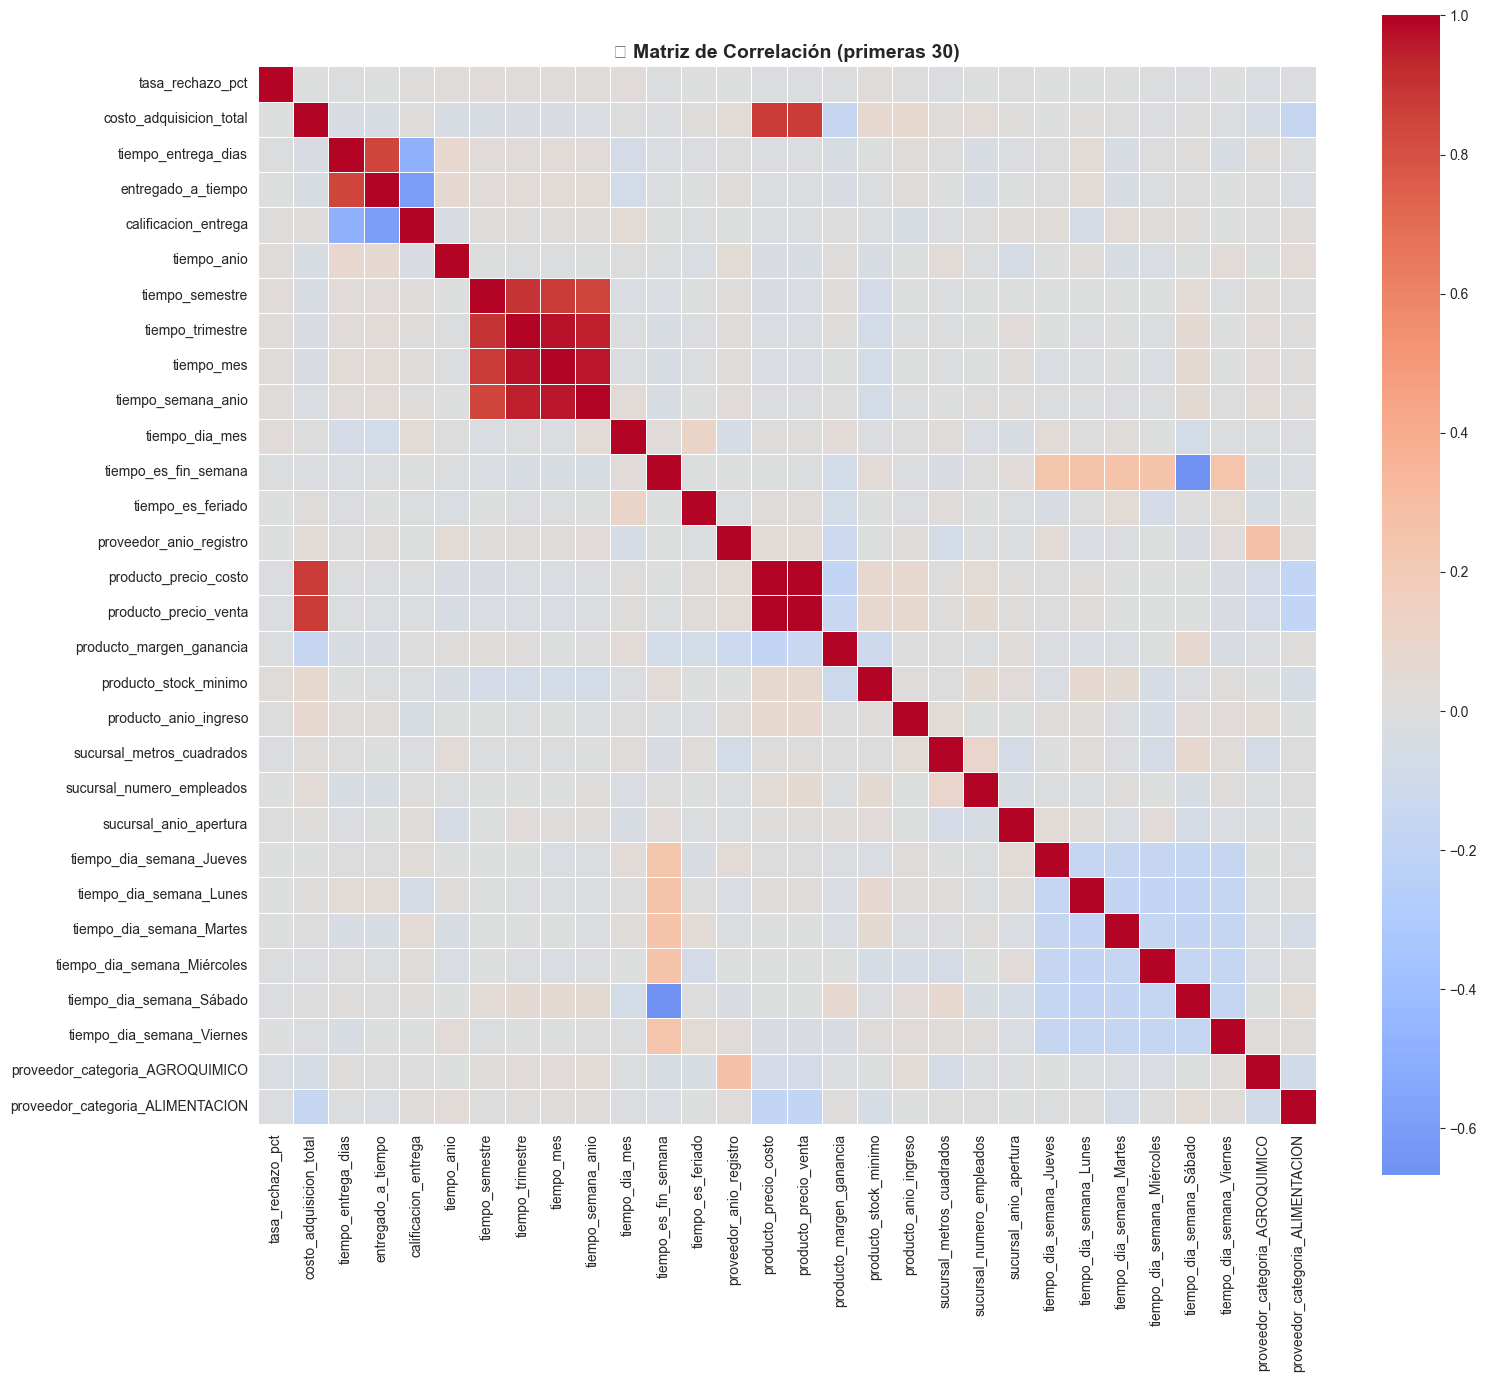

✅ Heatmap guardado


In [9]:
# Correlación
corr_matrix = df_encoded.corr()

fig, ax = plt.subplots(figsize=(16, 14))
n_features = min(30, df_encoded.shape[1])
corr_subset = corr_matrix.iloc[:n_features, :n_features]

sns.heatmap(corr_subset, cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title(f'🔥 Matriz de Correlación (primeras {n_features})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap guardado")

In [10]:
# Pares correlacionados
def find_correlated_pairs(corr_matrix, threshold=0.9):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlacion': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(pairs).sort_values('correlacion', ascending=False, key=abs)

highly_corr = find_correlated_pairs(corr_matrix, threshold=0.9)
print(f"🔴 Pares correlacionados (>0.9): {len(highly_corr)}")
if len(highly_corr) > 0:
    print(highly_corr.head(10).to_string())

🔴 Pares correlacionados (>0.9): 50
                            feature1                         feature2  correlacion
4    proveedor_categoria_AGROQUIMICO   producto_categoria_AGROQUIMICO          1.0
5     proveedor_categoria_AUTOMOTRIZ    producto_categoria_AUTOMOTRIZ          1.0
16        proveedor_categoria_VARIOS        producto_categoria_VARIOS          1.0
15        proveedor_categoria_VARIOS       proveedor_ciudad_MINNESOTA          1.0
7   proveedor_categoria_CONSTRUCCION  producto_categoria_CONSTRUCCION          1.0
6        proveedor_categoria_BEBIDAS       producto_categoria_BEBIDAS          1.0
8       proveedor_categoria_EMPAQUES      producto_categoria_EMPAQUES          1.0
9   proveedor_categoria_FARMACEUTICO  producto_categoria_FARMACEUTICO          1.0
11     proveedor_categoria_PAPELERIA     producto_categoria_PAPELERIA          1.0
10       proveedor_categoria_MUEBLES       producto_categoria_MUEBLES          1.0


In [11]:
# PCA previo a t-SNE para reducir dimensionalidad
from sklearn.decomposition import PCA
print("⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...")
pca_tsne = PCA(n_components=min(50, X_scaled.shape[1]))
X_pca_for_tsne = pca_tsne.fit_transform(X_scaled)

# t-SNE
print("⏳ Calculando t-SNE 2D...")
tsne = TSNE(n_components=2, perplexity=min(30, len(X_scaled)//3), random_state=42, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca_for_tsne)
print(f"✅ t-SNE completado")


⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...
⏳ Calculando t-SNE 2D...


✅ t-SNE completado


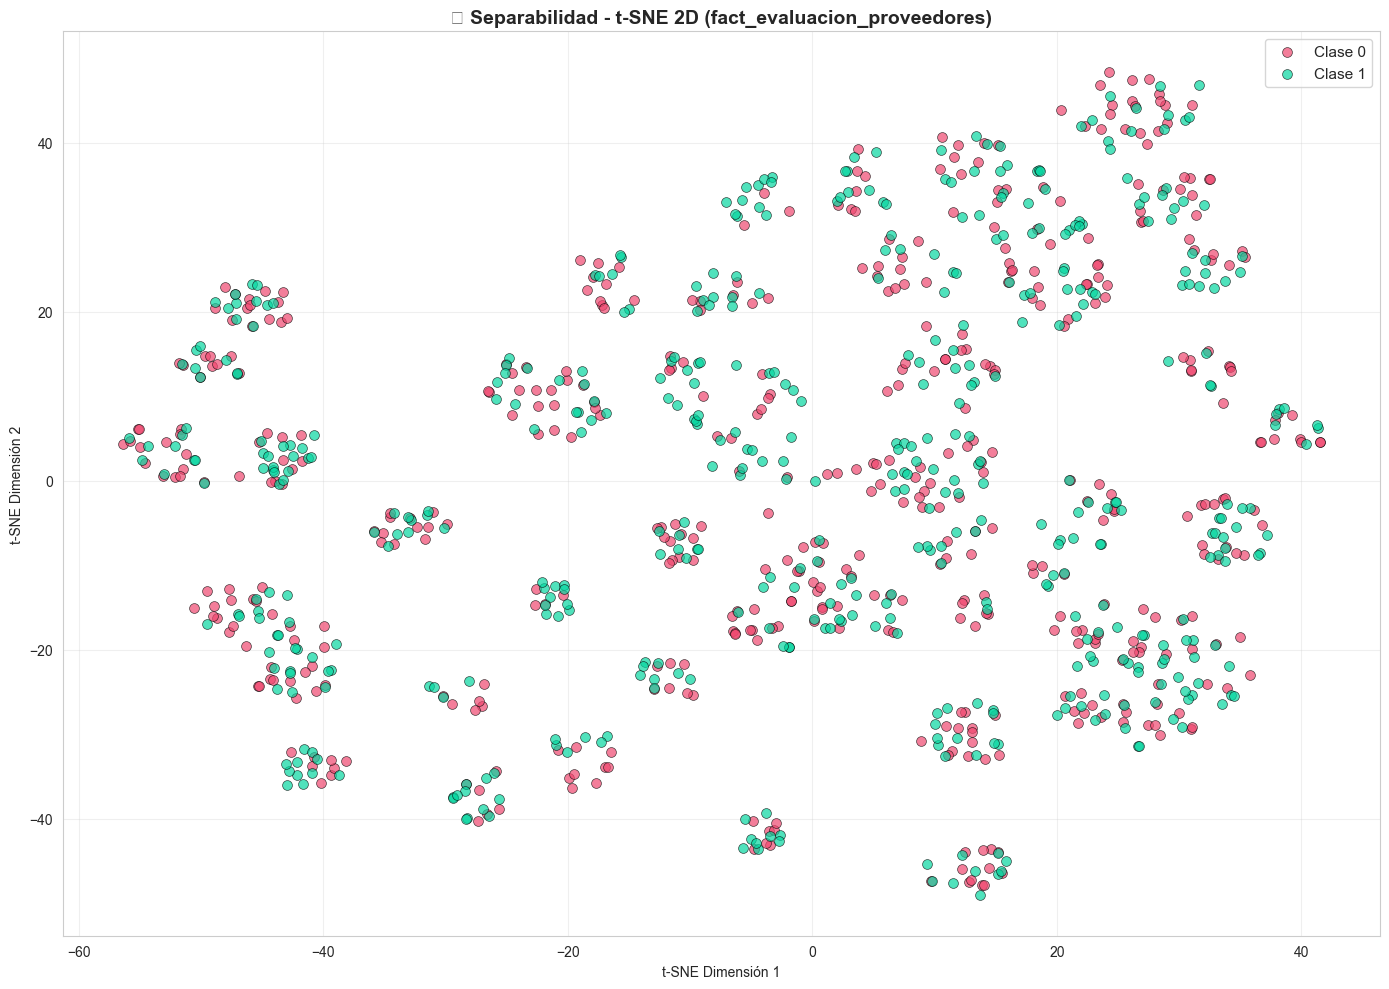

In [12]:
# Visualizar
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#EF476F', '#06D6A0']
names = ['Clase 0', 'Clase 1']

for i, (val, color, name) in enumerate(zip(sorted(y.unique()), colors, names)):
    mask = y == val
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_title('🎯 Separabilidad - t-SNE 2D (fact_evaluacion_proveedores)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimensión 1')
ax.set_ylabel('t-SNE Dimensión 2')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/02_tsne_separabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Métricas
silhouette = silhouette_score(X_scaled, y)
davies_bouldin = davies_bouldin_score(X_scaled, y)

print(f"📊 MÉTRICAS:")
print(f"Silhouette: {silhouette:.4f}")
print(f"Davies-Bouldin: {davies_bouldin:.4f}")

📊 MÉTRICAS:
Silhouette: -0.0019
Davies-Bouldin: 32.6018


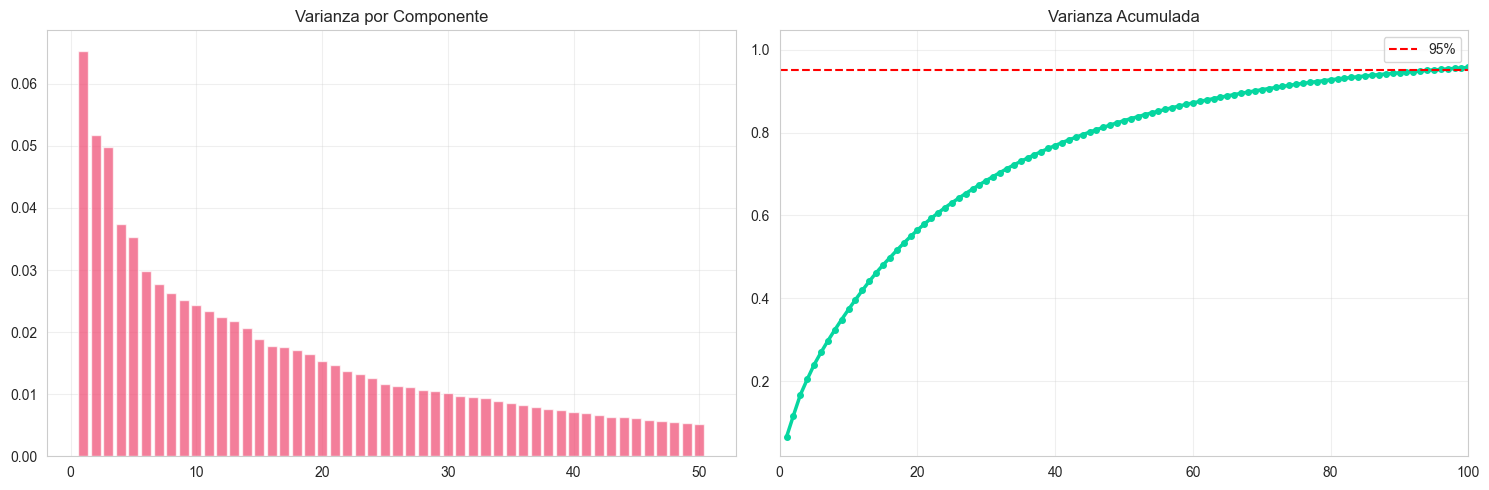

📈 PCA: 314 → 94 features (95% var)
Reducción: 70.1%


In [14]:
# PCA
pca = PCA()
pca.fit(X_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_comp_95 = np.argmax(cumsum >= 0.95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(range(1, min(51, len(pca.explained_variance_ratio_)+1)), 
        pca.explained_variance_ratio_[:50], color='#EF476F', alpha=0.7)
ax1.set_title('Varianza por Componente')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cumsum)+1), cumsum, 'o-', color='#06D6A0', linewidth=2.5, markersize=4)
ax2.axhline(0.95, color='red', linestyle='--', label='95%')
ax2.set_title('Varianza Acumulada')
ax2.set_xlim(0, min(100, len(cumsum)))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/03_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📈 PCA: {X_scaled.shape[1]} → {n_comp_95} features (95% var)")
print(f"Reducción: {(1-n_comp_95/X_scaled.shape[1])*100:.1f}%")

In [15]:
# Resumen
resumen = pd.DataFrame({
    'Métrica': ['Muestras', 'Features', 'Silhouette', 'Davies-Bouldin', 'Pares Corr.', 'PCA 95%'],
    'Valor': [X_scaled.shape[0], X_scaled.shape[1], f"{silhouette:.4f}", f"{davies_bouldin:.4f}", len(highly_corr), n_comp_95],
})
print("\n📊 RESUMEN:")
print(resumen.to_string(index=False))
resumen.to_csv('outputs/00_resumen_analisis.csv', index=False)


📊 RESUMEN:
       Métrica   Valor
      Muestras    1500
      Features     314
    Silhouette -0.0019
Davies-Bouldin 32.6018
   Pares Corr.      50
       PCA 95%      94


In [16]:
# Exportar datos preprocesados para el Notebook 02
import numpy as np
import os
os.makedirs('outputs', exist_ok=True)
np.savez('outputs/01_processed_data.npz', X_scaled=X_scaled, y=y)
print("✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz")

✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz
